In [ ]:
!pip install tensorflow-model-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you

In [ ]:
!pip install tf-explain


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00


In [ ]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.36.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.8.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [ ]:
import os
import cv2  # or use PIL as an alternative
import numpy as np
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import os
import json
from functools import partial
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers  import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D , BatchNormalization, Activation,InputLayer, GlobalMaxPooling2D, Dense, SeparableConv2D, Concatenate, Lambda
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras import layers, models
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Input, concatenate
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization
# from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import tensorflow_model_optimization.sparsity.keras as tfmot_keras
import tempfile
import datetime
import os
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical  # You can use np.eye as well for one-hot encoding
# Define a log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
path = '/content/drive/MyDrive/Aple_Cropped'
model_path = path + '/arduinoML.h5'
tflite_path = path + '/pruned_model.tflite'
selected_index = 310

In [ ]:


# Function to load images, resize, normalize, and label them
def load_images_from_folder(*folders):
    images = []
    labels = []
    for folder in folders:
        # Get the list of subfolders (labels)
        print("Current folder: " + folder)

        for label in os.listdir(folder):
            count = 0
            print("Current label: " + label)
            label_folder = os.path.join(folder, label)
            if os.path.isdir(label_folder):
                for image_name in os.listdir(label_folder):
                    #print("Image name: " + image_name)
                    image_path = os.path.join(label_folder, image_name)
                    try:
                        # Load the image
                        img = Image.open(image_path)
                        # Check if the image is PNG and convert to JPG if necessary
                        if img.format == 'PNG':
                            img = img.convert('RGB')
                            #print(f"Converting {image_name} to JPG format.")
                        # Resize the image to 256x256
                        img = img.resize((256, 256))
                        # Convert the image to numpy array and normalize
                        img_array = np.array(img)/ 255.0
                        # img_array = np.array(img)
                        # Convert the array to float32
                        img_array = img_array.astype(np.float32)
                        # img_array = img_array.astype(np.uint8)
                        #print(img_array.shape)
                        images.append(img_array)
                        labels.append(label)
                        count += 1
                    except Exception as e:
                        print(f"Error loading image {image_path}: {e}")
                    #print(f"Folder: {label_folder}, Image: {image_name}, Label: {label}, Count: {count}")
    return np.array(images), np.array(labels)

# path to directory


images_np, labels_np = load_images_from_folder(path)

# split into training and validation data
images_train, images_test, labels_train, labels_test = train_test_split(
    images_np, labels_np, test_size=0.1, random_state=42, shuffle=True)

# Encode the labels into integers
label_encoder = LabelEncoder()

labels_train_encoded = label_encoder.fit_transform(labels_train)
labels_test_encoded = label_encoder.fit_transform(labels_test)

# One-hot encode the integer labels
labels_train_one_hot = to_categorical(labels_train_encoded)
labels_test_one_hot = to_categorical(labels_test_encoded)


# np image to use gradcam on from the testing images list
selected_image_np = images_test[selected_index]


print(f"Images shape: {images_np.shape}")
print(f"One-hot encoded labels shape (training): {labels_train_one_hot.shape}")
print(f"One-hot encoded labels shape (testing): {labels_test_one_hot.shape}")

tensor_reshaped = tf.reshape(labels_train_one_hot, (-1, 1, 1, 4))

encoded_justValue = tf.reshape(labels_train_encoded, (-1, 1, 1, 1))


Current folder: /content/drive/MyDrive/Aple_Cropped
Current label: BR
Current label: AR
Current label: BS
Current label: H
Current label: pruned_model.tflite
Current label: variables
Error loading image /content/drive/MyDrive/Aple_Cropped/variables/variables.data-00000-of-00001: cannot identify image file '/content/drive/MyDrive/Aple_Cropped/variables/variables.data-00000-of-00001'
Error loading image /content/drive/MyDrive/Aple_Cropped/variables/variables.index: cannot identify image file '/content/drive/MyDrive/Aple_Cropped/variables/variables.index'
Current label: assets
Current label: saved_model.pb
Current label: fingerprint.pb
Current label: arduinoML.h5
Images shape: (4074, 256, 256, 3)
One-hot encoded labels shape (training): (3666, 4)
One-hot encoded labels shape (testing): (408, 4)


In [ ]:

# Define the shared convolutional model for a single channel


def build_shared_conv_model(channel_shape=(256, 256, 1)):
    inputs = Input(shape=channel_shape)
    x = Conv2D(12, 3, activation='relu', padding='same', strides =2 )(inputs)


    x = SeparableConv2D(24, 3, activation='relu', padding='same', strides =2)(x)


    x = SeparableConv2D(24, 3, activation='relu', padding='same', strides =2)(x)


    x = SeparableConv2D(48, 3, activation='relu', padding='same', strides =2)(x)


    x = SeparableConv2D(48, 3, activation='relu', padding='same', strides =2)(x)


    x = SeparableConv2D(48, 3, activation='relu', padding='same', strides =2)(x)


    x = SeparableConv2D(16, 3, activation='relu', padding='same', strides =2)(x)




    return tf.keras.Model(inputs=inputs, outputs=x)



fullscale_image = Input(shape=(256, 256, 3))

shared_conv_model = build_shared_conv_model()
output_channel_1 = shared_conv_model(fullscale_image[..., 0:1])
output_channel_2 = shared_conv_model(fullscale_image[..., 1:2])
output_channel_3 = shared_conv_model(fullscale_image[..., 2:3])


features = Concatenate(axis=-1)([output_channel_1, output_channel_2, output_channel_3])

features = Conv2D(32, 1, activation='relu', padding='same')(features)


classification = GlobalMaxPooling2D()(features)

prediction = tf.keras.layers.Dense(16, activation = 'relu')(classification)

prediction = tf.keras.layers.Dense(4, activation = 'softmax')(prediction)



# Define the full model
model = tf.keras.Model(inputs=fullscale_image, outputs=prediction)

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 2, 2, 16)  │      9,556 │ get_item_3[0][0], │
│ (Functional)        │                   │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2, 2, 48)  │          0 │ functional_2[0][… │
│ (Concatenate)       │                   │            │ functional_2[1][… │
│                     │                   │            │ functional_2[2][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 2, 2, 32)  │      1,568 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_3[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │         68 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,720 (45.78 KB)

 Trainable params: 11,720 (45.78 KB)

 Non-trainable params: 0 (0.00 B)

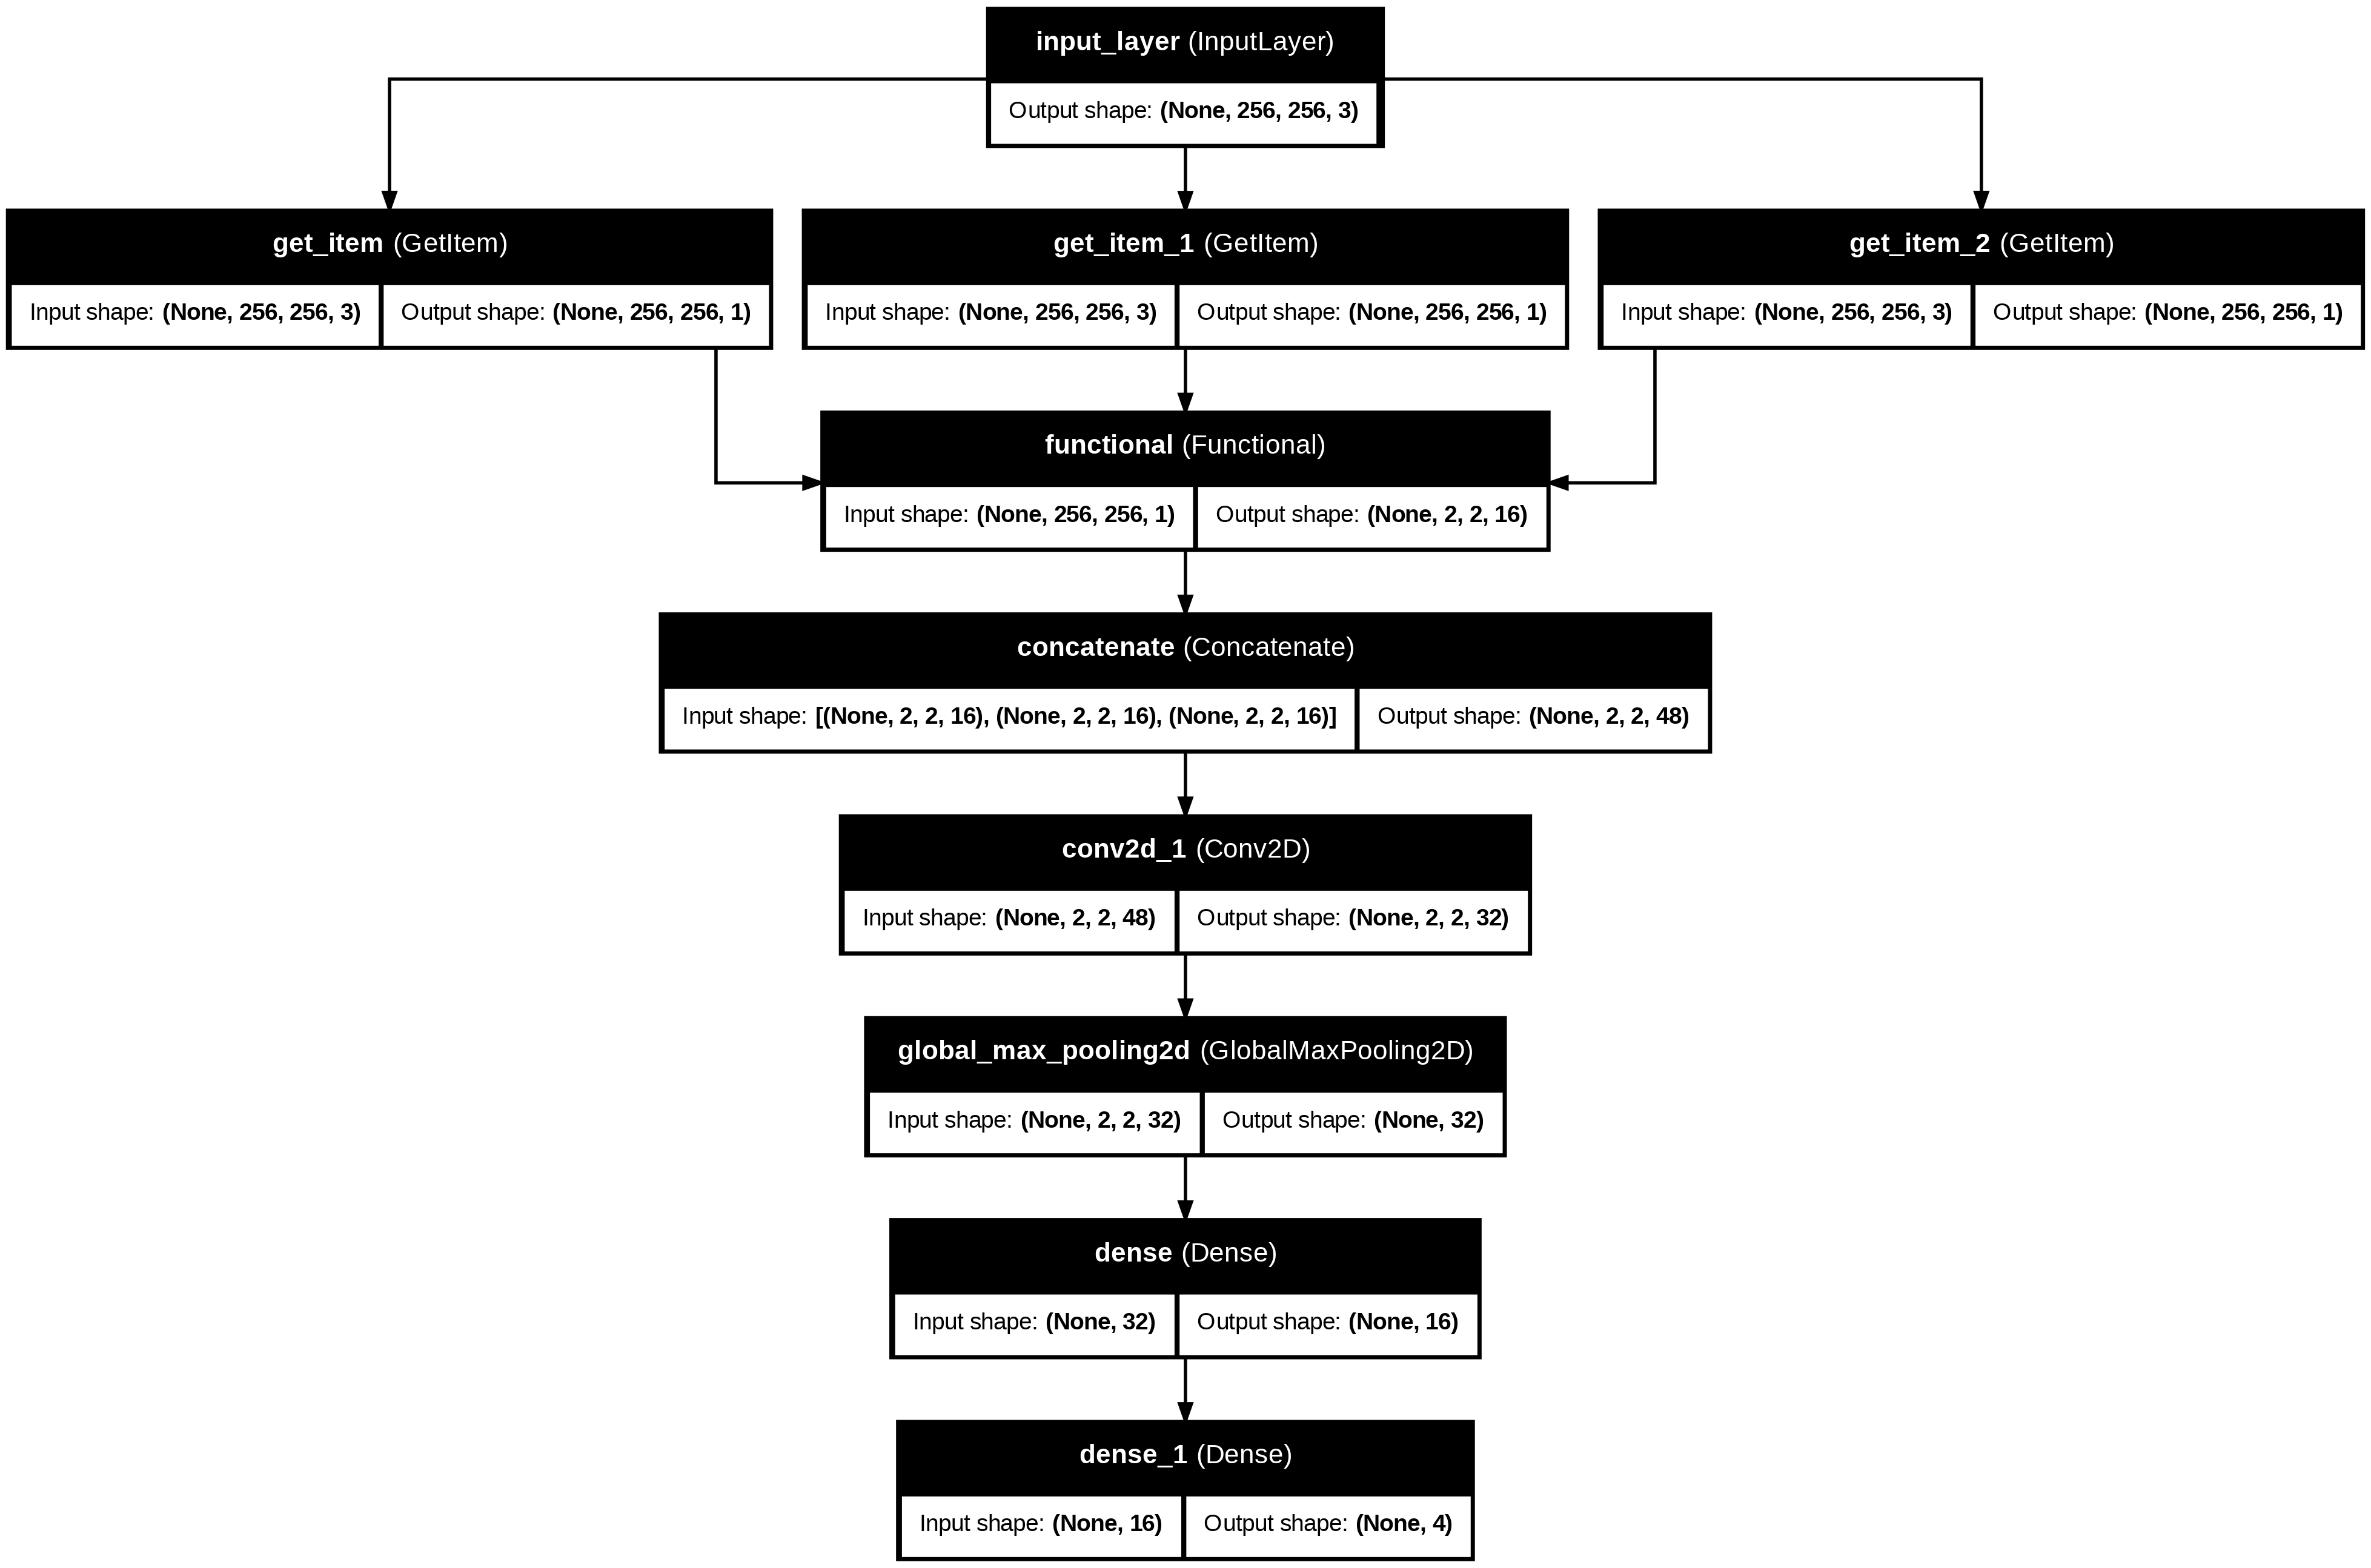

In [ ]:


tf.keras.utils.plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

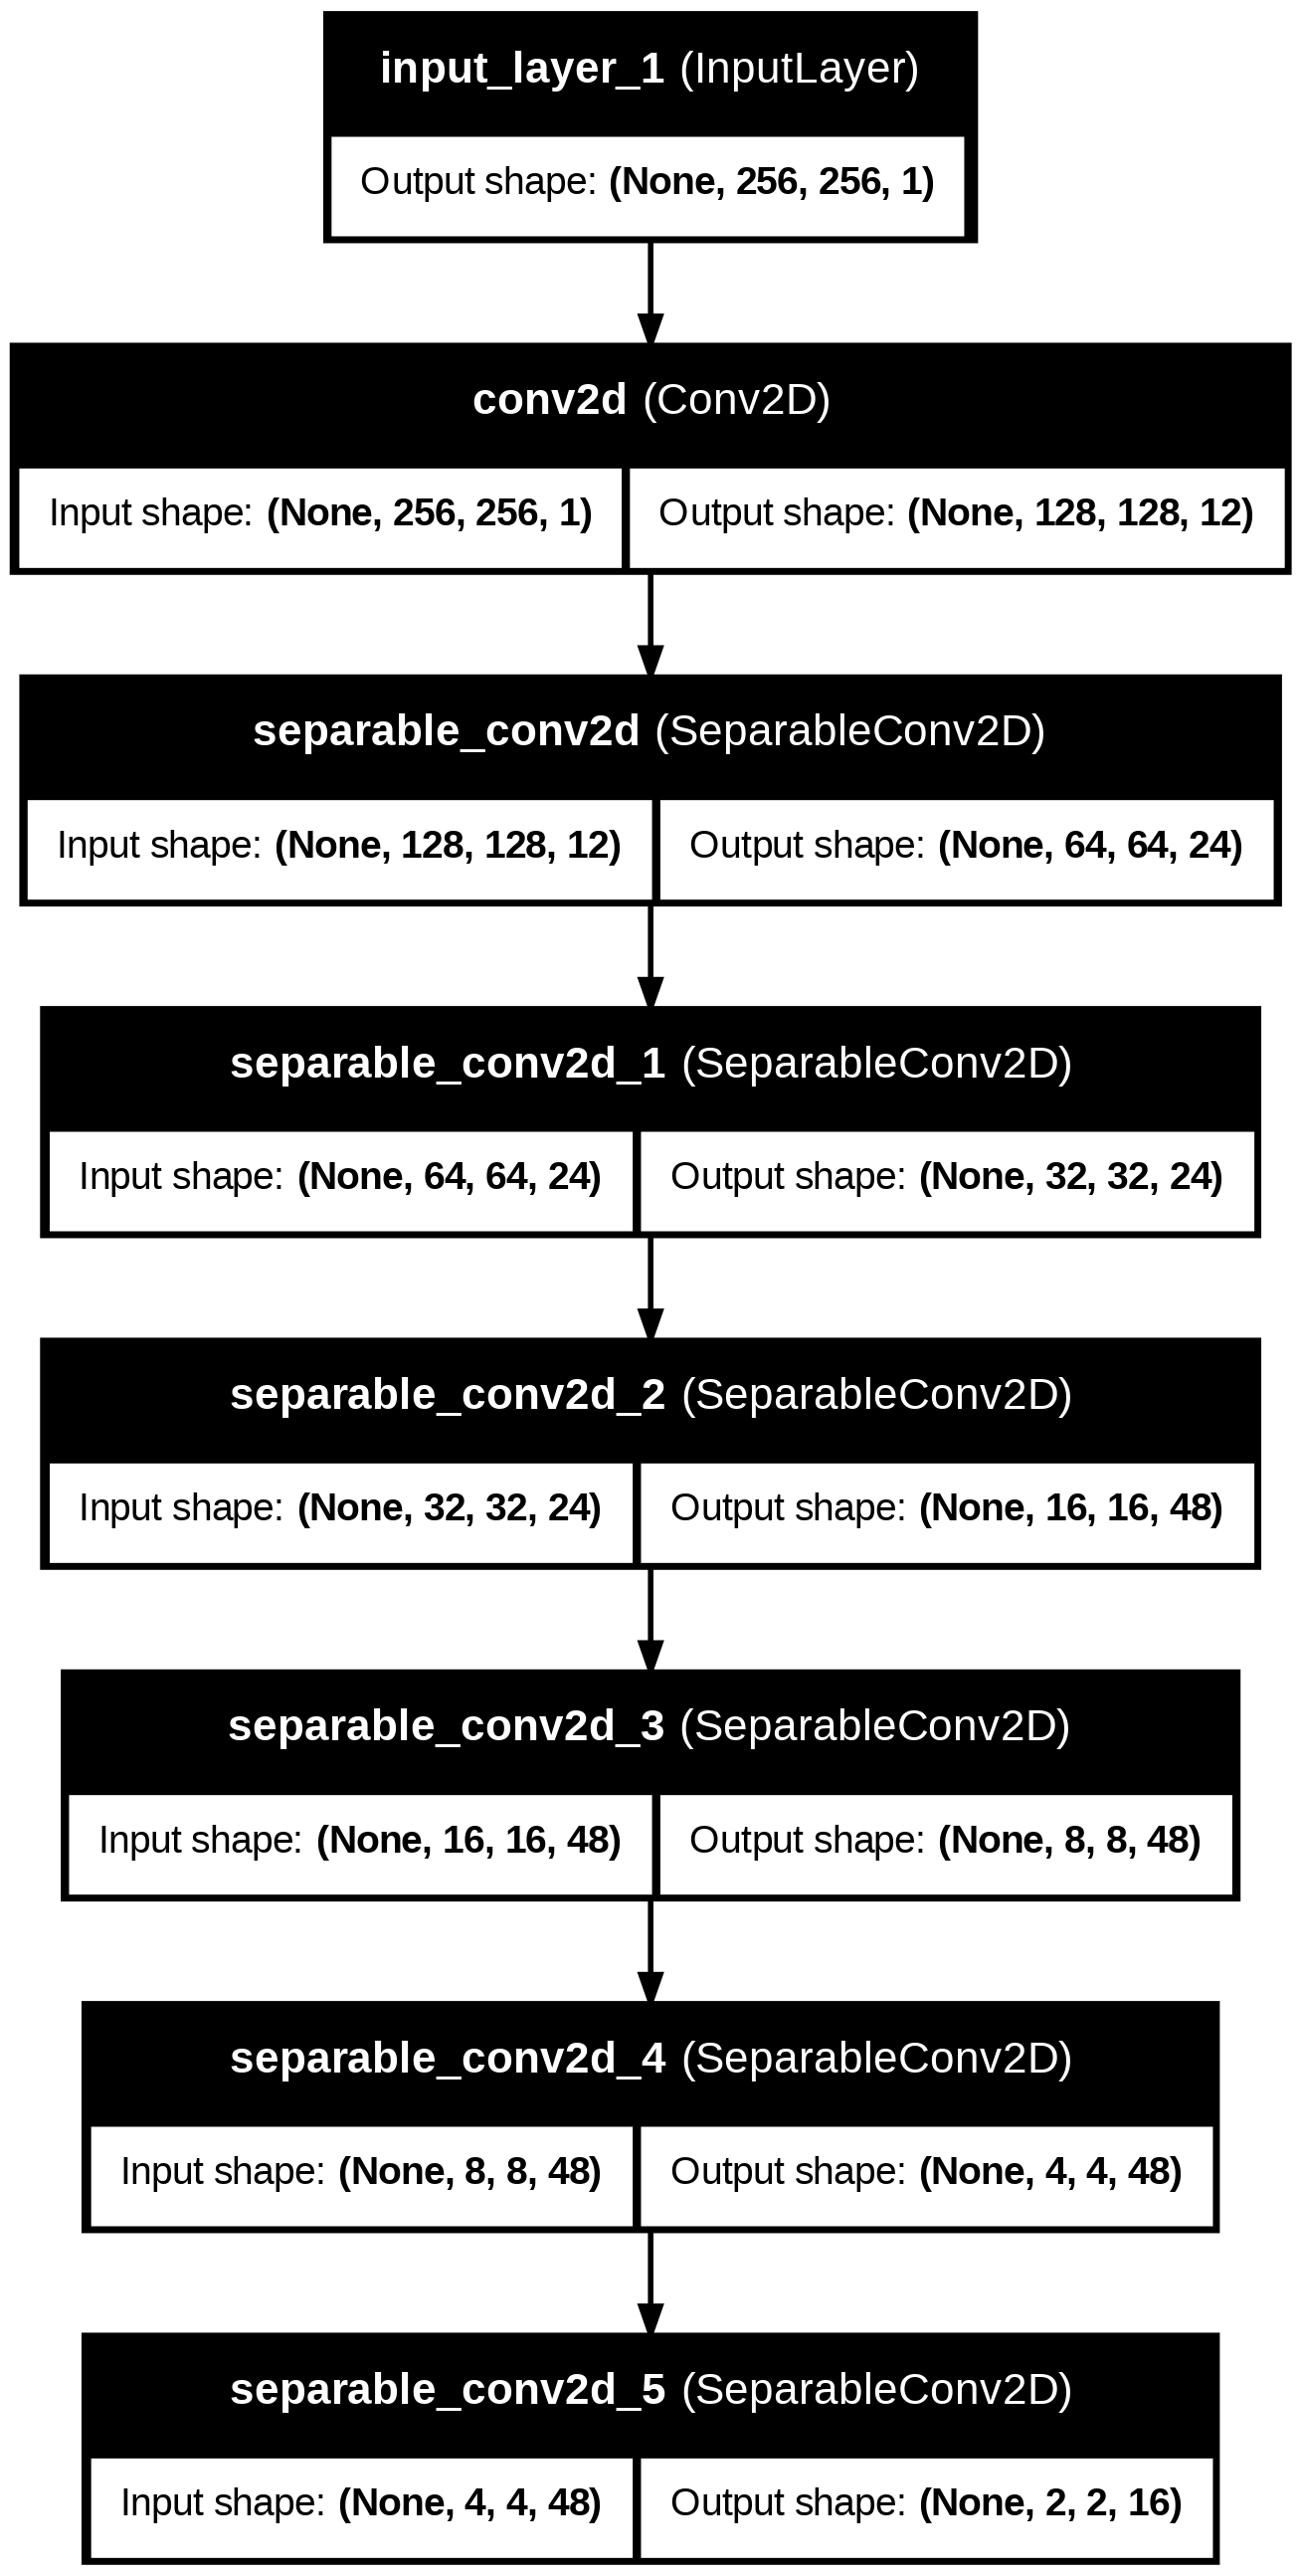

In [ ]:
tf.keras.utils.plot_model(shared_conv_model, to_file='shared_conv_model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
history = model.fit(
    images_train,
    labels_train_one_hot,
    epochs=75,
    validation_data=(images_test, labels_test_one_hot)
)


Epoch 1/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 43s 259ms/step - accuracy: 0.2708 - loss: 1.3852 - val_accuracy: 0.2500 - val_loss: 1.3805
Epoch 2/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2787 - loss: 1.3781 - val_accuracy: 0.4755 - val_loss: 1.1858
Epoch 3/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5062 - loss: 1.1394 - val_accuracy: 0.6544 - val_loss: 0.7736
Epoch 4/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6463 - loss: 0.8364 - val_accuracy: 0.7525 - val_loss: 0.6481
Epoch 5/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7067 - loss: 0.7164 - val_accuracy: 0.7574 - val_loss: 0.6545
Epoch 6/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7152 - loss: 0.7161 - val_accuracy: 0.7770 - val_loss: 0.6060
Epoch 7/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7422 - loss: 0.6631 - val_accuracy: 0.7475 - val_loss: 0.6417
Epoch 8/75
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7470 - loss: 0.6401 - val_ac

In [ ]:
print(model.predict(tf.constant(images_test)) )
model.save(model_path, overwrite=True, save_format='h5')

#tf.saved_model.save(model, "/content/drive/MyDrive/Aple_Cropped/")

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 351ms/step


[[9.9999678e-01 1.5051448e-10 3.2329640e-06 1.6599540e-13]
 [1.0000000e+00 2.8737792e-11 1.9968635e-08 3.1852499e-16]
 [1.5479888e-01 8.4469724e-01 5.0387462e-04 1.2505373e-09]
 ...
 [9.9978852e-01 1.8164911e-08 2.1119308e-04 1.6744988e-07]
 [3.2067848e-07 3.3778626e-05 3.5321007e-06 9.9996245e-01]
 [9.9960816e-01 4.2107368e-07 3.8604002e-04 5.3261579e-06]]


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[9.9999678e-01 1.5051448e-10 3.2329640e-06 1.6599540e-13]
 [1.0000000e+00 2.8737792e-11 1.9968635e-08 3.1852499e-16]
 [1.5479888e-01 8.4469724e-01 5.0387462e-04 1.2505373e-09]
 ...
 [9.9978852e-01 1.8164911e-08 2.1119308e-04 1.6744988e-07]
 [3.2067848e-07 3.3778626e-05 3.5321007e-06 9.9996245e-01]
 [9.9960816e-01 4.2107368e-07 3.8604002e-04 5.3261579e-06]]
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Confusion Matrix:
 [[103   1   2   1]
 [  5 105   7  10]
 [  2   3  87  10]
 [  1   0   1  70]]


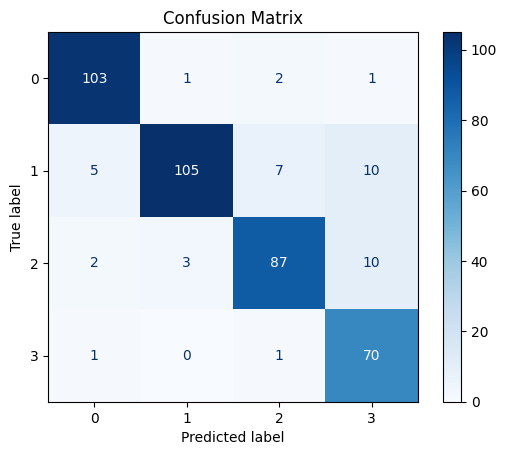

115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
[[9.9999571e-01 2.1122796e-06 2.1373864e-06 2.2966972e-11]
 [2.3216002e-04 9.7673291e-01 6.2001636e-04 2.2414871e-02]
 [2.5309993e-05 2.1991676e-05 5.8319314e-05 9.9989438e-01]
 ...
 [3.2073262e-07 9.8697793e-01 1.3021718e-02 2.8455402e-08]
 [4.0287559e-06 6.2602489e-08 2.3777732e-03 9.9761802e-01]
 [3.5607968e-12 2.7706708e-09 9.9992895e-01 7.1053677e-05]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[5.9318844e-15 9.9998844e-01 4.1152310e-07 1.1212199e-05]]
Validation Accuracy: 0.8946078431372549


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
#model = keras.models.load_model(model_path)
print(model.predict(tf.constant(images_test)) )
y_pred_prob = model.predict(tf.constant(images_test))  # Get predicted probabilities of testing images
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

cm = confusion_matrix(labels_test_encoded, y_pred)

# Print confusion matrix
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels_test_encoded))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(labels_test_encoded, y_pred)
print(model.predict(tf.constant(images_train)) )

print(model.predict(tf.constant(images_test[[30]])) )
print(f"Validation Accuracy: {accuracy}")

In [ ]:
!pip install tf-explain  # Make sure tf-explain is installed

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tf_explain.core.grad_cam import GradCAM
import random

def run_gradcam_for_images(model, images_test,  iterations=250):
    """
    Run Grad-CAM on a random set of test images.

    Parameters:
        model (tf.keras.Model): The trained model to use.
        images_test (np.ndarray): Array of test images.
        start_index (int): Starting index for images_test.
        max_index (int): Maximum index for images_test.
        iterations (int): Number of iterations to run Grad-CAM.

    Returns:
        None
    """
    grad_cam = GradCAM()

    for _ in range(iterations):
        # Randomly select an image index within the range
        image_index = random.randint(1, 400)

        # Get the image and preprocess it
        source = images_test[image_index]
        preprocessed_source = np.expand_dims(source, axis=0)  # Add batch dimension

        # Predict the target class
        target_class = np.argmax(model.predict(preprocessed_source))

        # Generate Grad-CAM explanations
        data = (preprocessed_source, None)
        target_layer = model.get_layer("conv2d_7")  # Adjust layer name as needed
        explanations = grad_cam.explain(data, model, class_index=target_class, layer_name=target_layer.name)

        # Visualize the results
        original_image = np.squeeze(source)  # Remove batch dimension if necessary
        visualize_gradcam(original_image, explanations)

# Define the visualization function
def visualize_gradcam(original_image, heatmap):
    plt.figure(figsize=(10, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image)
    plt.axis("off")

    # GradCAM heatmap overlay
    plt.subplot(1, 2, 2)
    plt.title("GradCAM Heatmap")
    plt.imshow(original_image)
    plt.imshow(heatmap, cmap="viridis", alpha=0.8)  # Overlay heatmap with transparency
    plt.axis("off")

    plt.show()

# Example usage
run_gradcam_for_images(model, images_test, iterations=100)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


ValueError: No such layer: conv2d_7. Existing layers are: ['input_layer', 'functional', 'concatenate', 'conv2d_1', 'global_max_pooling2d', 'dense', 'dense_1'].

In [ ]:
model.export('/content/drive/MyDrive/soil/model')

Saved artifact at '/content/drive/MyDrive/soil/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139224121290448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271891984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271892752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271892368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271892560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271891024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271891792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271891408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271892944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139214271893136: TensorSpec(shape=(), dtype=tf.resource, name=No

In [ ]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --saved_model_tags=serve \
    "/content/drive/MyDrive/soil/model" \
    "/content/drive/MyDrive/soil/jsmodel"


2025-08-31 23:01:25.372769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756681285.394340   37190 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756681285.401002   37190 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756681285.417175   37190 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756681285.417206   37190 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756681285.417209   37190 computation_placer.cc:177] computation placer alr